In [33]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [34]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec
import matplotlib

import sys

sys.path.append("../src")

import jax
import jax.numpy as jnp

import netket as nk
import numpy as np

from netket.operator.spin import sigmax, sigmaz
from metropolis import LocalDoubleFlipRule
from netket.experimental.dynamics import RK45, Heun
from callbacks import (
    get_qgt_spectrum_callback,
    get_umbrella_monitor_callback,
    get_tdvp_monitor_callback,
    get_parameter_save_callback,
)
from logger import Logger

from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt

import argparse
import numpy as np

from gaussian_state import GaussianState
from tfim_exact_majorana import run_ed


In [35]:
import jax.numpy as jnp
import numpy as np
import flax.linen as nn

L = 2
N = L**2
J0 = 1.0
hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=0)

graph = nk.graph.Grid((L, L), pbc=False)
hamiltonian = nk.operator.Heisenberg(hilbert, graph, J=1 / 4)


def get_vstate(n_samples, seed=100):
    sampler = nk.sampler.MetropolisExchange(hilbert, graph=graph, n_chains=n_samples)
    model = nk.models.RBM(
        alpha=1/N,
        param_dtype=complex,
        use_visible_bias=False,
        hidden_bias_init=nn.initializers.normal(1e-1),
        visible_bias_init=nn.initializers.normal(1e-1),
        kernel_init=nn.initializers.normal(1e-1),
    )
    return nk.vqs.MCState(
        sampler=sampler, model=model, n_samples=n_samples, seed=seed, sampler_seed=seed
    )


def get_vstate_parameters(n_samples, seed):
    vstate = get_vstate(n_samples,seed)

    # Thermalize
    for i in range(0):
        vstate.sample(n_samples=n_samples)
    e0 = nk.exact.lanczos_ed(hamiltonian)

    gs = nk.driver.VMC_SR(
        hamiltonian,
        optimizer=nk.optimizer.Sgd(0.01),
        variational_state=vstate,
        diag_shift=1e-4,
    )
    gs.run(1000, callback=lambda s, l, d: d._loss_stats.mean > e0 + 1e-3)
    return vstate.parameters

params_seed = {}
for seed in [100,200, 300, 400, 500]:
    vstate = get_vstate(2**10, seed)
    print(vstate.n_parameters)
    parameters = get_vstate_parameters(2**10, seed)
    vstate.parameters = parameters.copy()
    params_seed[seed] = parameters.copy()
    e0 = nk.exact.lanczos_ed(hamiltonian)
    estimated_e = vstate.expect(hamiltonian)
    print(f"GS energy {e0}")
    print(f"variational energy {estimated_e}")

5
Automatic SR implementation choice:  QGT


KeyboardInterrupt: 

In [ ]:

L = 2
N = L**2
J0 = 1.0
hilbert = nk.hilbert.Spin(s=1 / 2, N=N, total_sz=0)

graph = nk.graph.Grid((L, L), pbc=False)
hamiltonian = nk.operator.Heisenberg(hilbert, graph, J=1 / 4)

graph = nk.graph.Chain(N, pbc=True)

deltaJ = -2
vertical_bonds = []
for x in range(L):
    for y in range(L - 1):
        i = x * L + y
        j = x * L + (y + 1)
        vertical_bonds.append((i, j))
vertical_bonds_graph = nk.graph.Graph(edges=vertical_bonds)
vertical_heisenberg = nk.operator.Heisenberg(hilbert,  vertical_bonds_graph, J=deltaJ/4)
quench_hamiltonian = hamiltonian + vertical_heisenberg
single_edge = nk.graph.Graph(edges=(vertical_bonds[0],))
s_correlator = nk.operator.Heisenberg(hilbert, single_edge, J=1./4)

fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("s_corr", "Mean"),
    ("s_corr", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("qgt_spectrum", "values"),
)


def measure_corr(step, log, driver):
    log['s_corr'] = driver.state.expect(s_correlator)
    return True

In [ ]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = quench_hamiltonian.to_dense()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
vstate = get_vstate(2**10)
vstate.parameters = parameters.copy()
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert to QuTiP
Scorr_qutip = qt.Qobj(s_correlator.to_dense() )

# Time evolution parameters
T = 6
times_exact_heisenberg = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact_heisenberg = []
for t in times_exact_heisenberg:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    corr = qt.expect(Scorr_qutip, psi_t)
    magnetizations_exact_heisenberg.append(corr)

In [ ]:
from schmitt_tdvp_blur import TDVPSchmittBlur
from schmitt_tdvp import TDVPSchmitt


def fit_bridge(q, n_samples_tvmc, seed):
    T = 1.5 * 4
    save_times = np.linspace(0.0, T, 600)
    exp_name = f"blur_{n_samples_tvmc}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}_{seed}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/HEISENBERG_{N}/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate = get_vstate(n_samples_tvmc, seed)
    vstate.parameters = params_seed[seed].copy()
    for i in range(1000):
        vstate.sample()
    callbacks = []
    callbacks.append(measure_corr)
    callbacks.append(get_parameter_save_callback(save_times, logger))
    callbacks.append(get_qgt_spectrum_callback(save_times))
    if q == 0:
        tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    else:
        tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)

    # integrator = RK45(1e-3, adaptive=False, rtol=1e-6, dt_limits=(1e-5, 1e-2))
    integrator = Heun(1e-3)
    tvmc_kwargs = {}
    if q == 0:
        driver = TDVPSchmitt(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )
    else:
        driver = TDVPSchmittBlur(
            quench_hamiltonian,
            vstate,
            integrator,
            t0=0,
            q=q,
            holomorphic=False,
            snr_atol=2,
            rcond=1e-14,
            rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback=callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [ ]:
# fit_bridge(0.0, 2**14)
for seed in [100, 200,300,400,500]:
    fit_bridge(0.0, 2**14, seed=seed)

Data exists, skipping...
File not found


  0%|          | 0.00/6.00 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 122.147                                                                                                  │
│ ├── (4.2%) | MCState.expect : 5.122 s                                                                           │
│ ├── (3.4%) | QGTJacobian_DefaultConstructor : 4.186 s                                                           │
│ │   └── (45.9%) | jacobian : 1.921 s                                                                            │
│ ├── (26.3%) | MCState.local_estimators : 32.096 s                                                               │
│ │   └── (68.6%) | MCState.sample : 22.009 s                                                                     │
│ │       └── (72.2%) | sampling n_discarded samples : 15.900 s                                                   │
│ └── (12.9%) | _impl : 15.776 s                                        

  0%|          | 0.00/6.00 [00:00<?, ?it/s]

╭────────────────────────────────────────────── Timing Information ───────────────────────────────────────────────╮
│ Total: 122.360                                                                                                  │
│ ├── (3.9%) | MCState.expect : 4.802 s                                                                           │
│ ├── (3.4%) | QGTJacobian_DefaultConstructor : 4.145 s                                                           │
│ │   └── (44.5%) | jacobian : 1.844 s                                                                            │
│ ├── (26.3%) | MCState.local_estimators : 32.181 s                                                               │
│ │   └── (69.2%) | MCState.sample : 22.257 s                                                                     │
│ │       └── (72.0%) | sampling n_discarded samples : 16.019 s                                                   │
│ └── (12.3%) | _impl : 15.094 s                                        

KeyboardInterrupt: 

Restored: True


/tmp/ipykernel_2067777/3695010556.py:94: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(


Restored: True


/tmp/ipykernel_2067777/3695010556.py:94: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(


Restored: True


/tmp/ipykernel_2067777/3695010556.py:94: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z.plot(


File not found


AssertionError: 

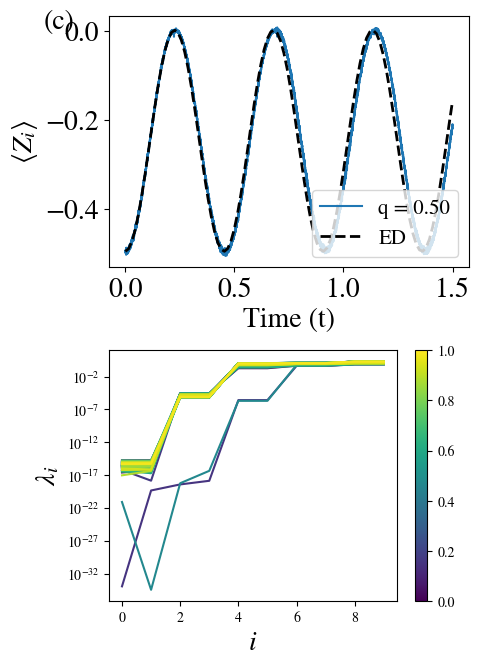

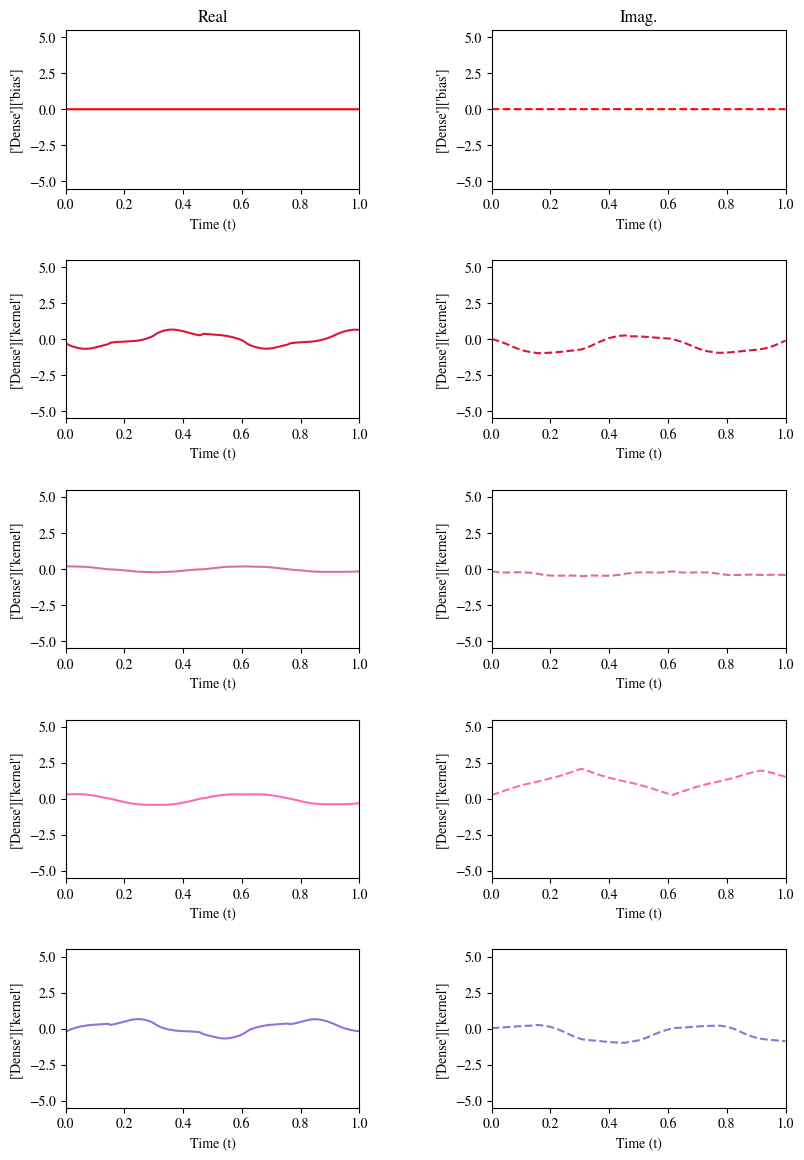

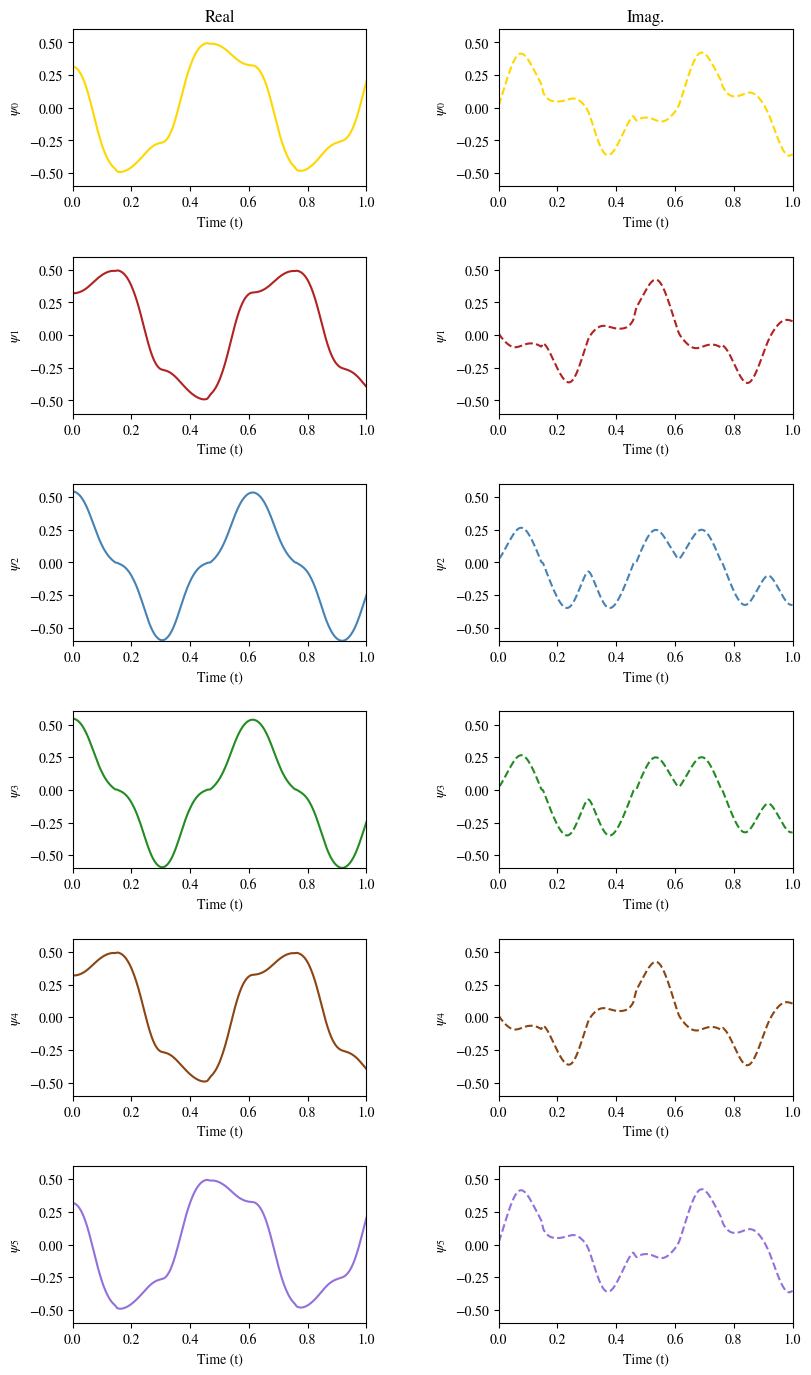

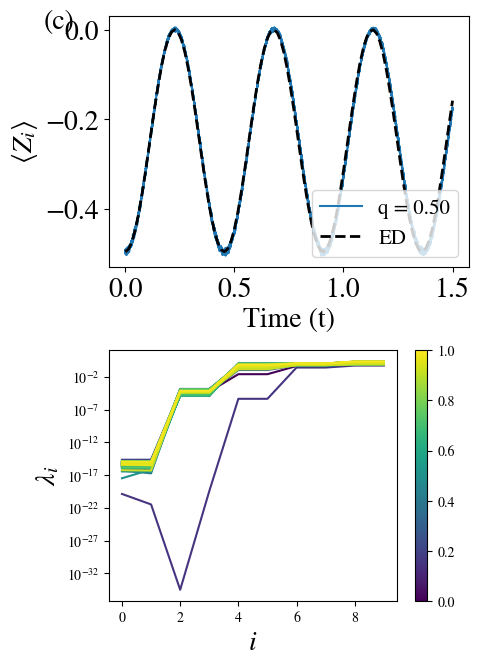

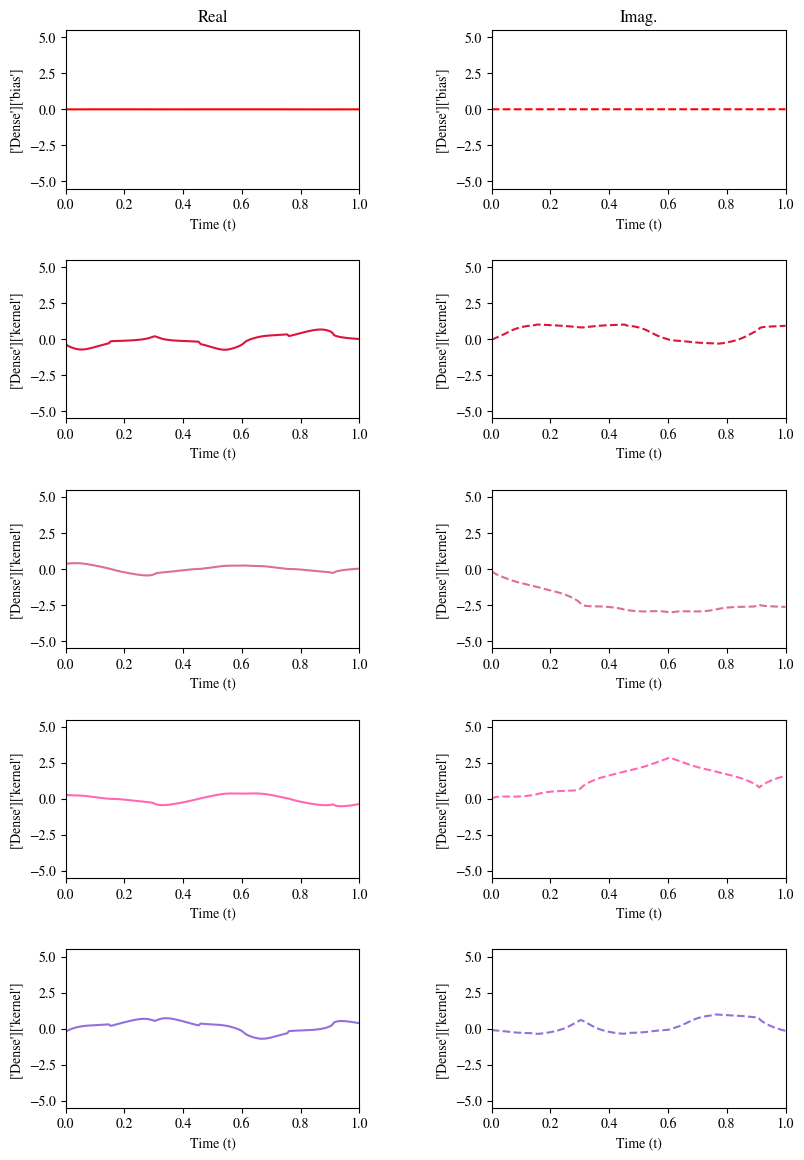

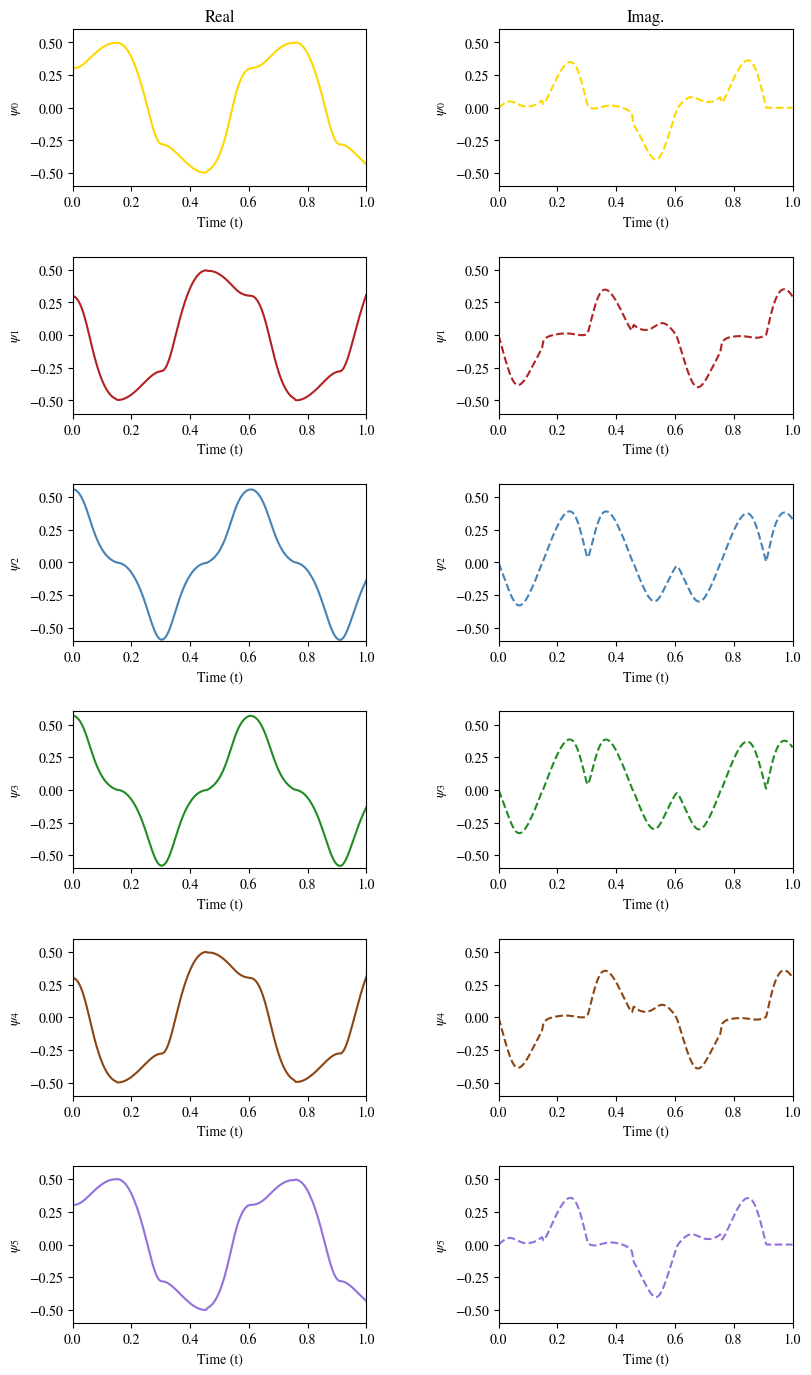

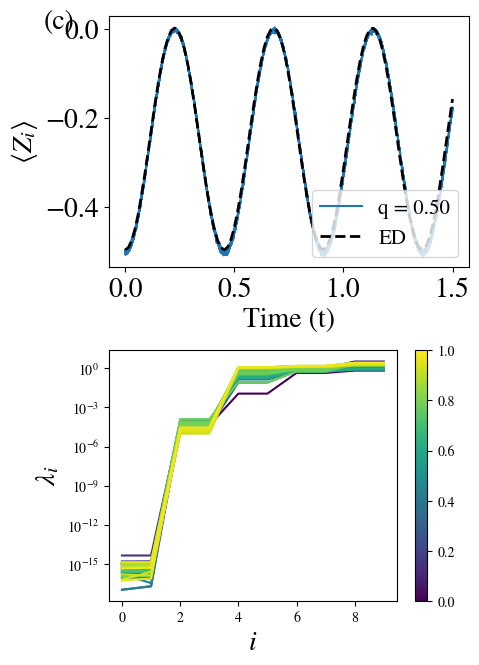

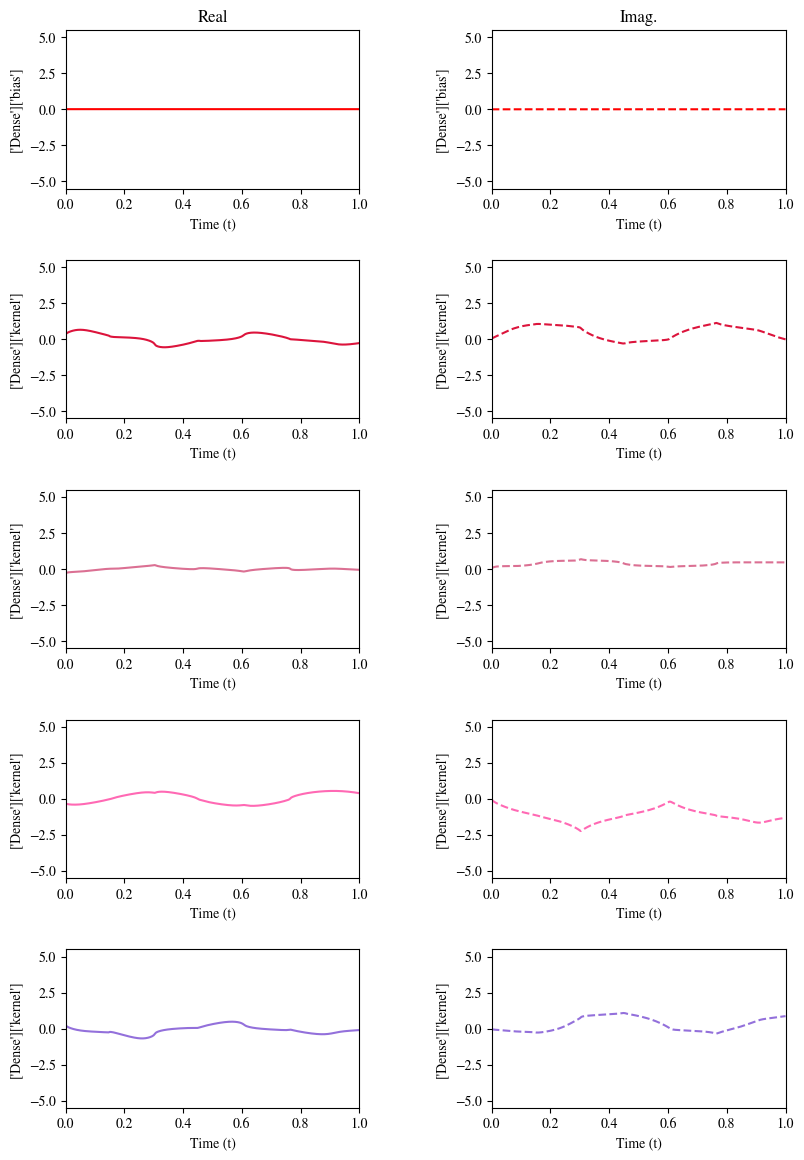

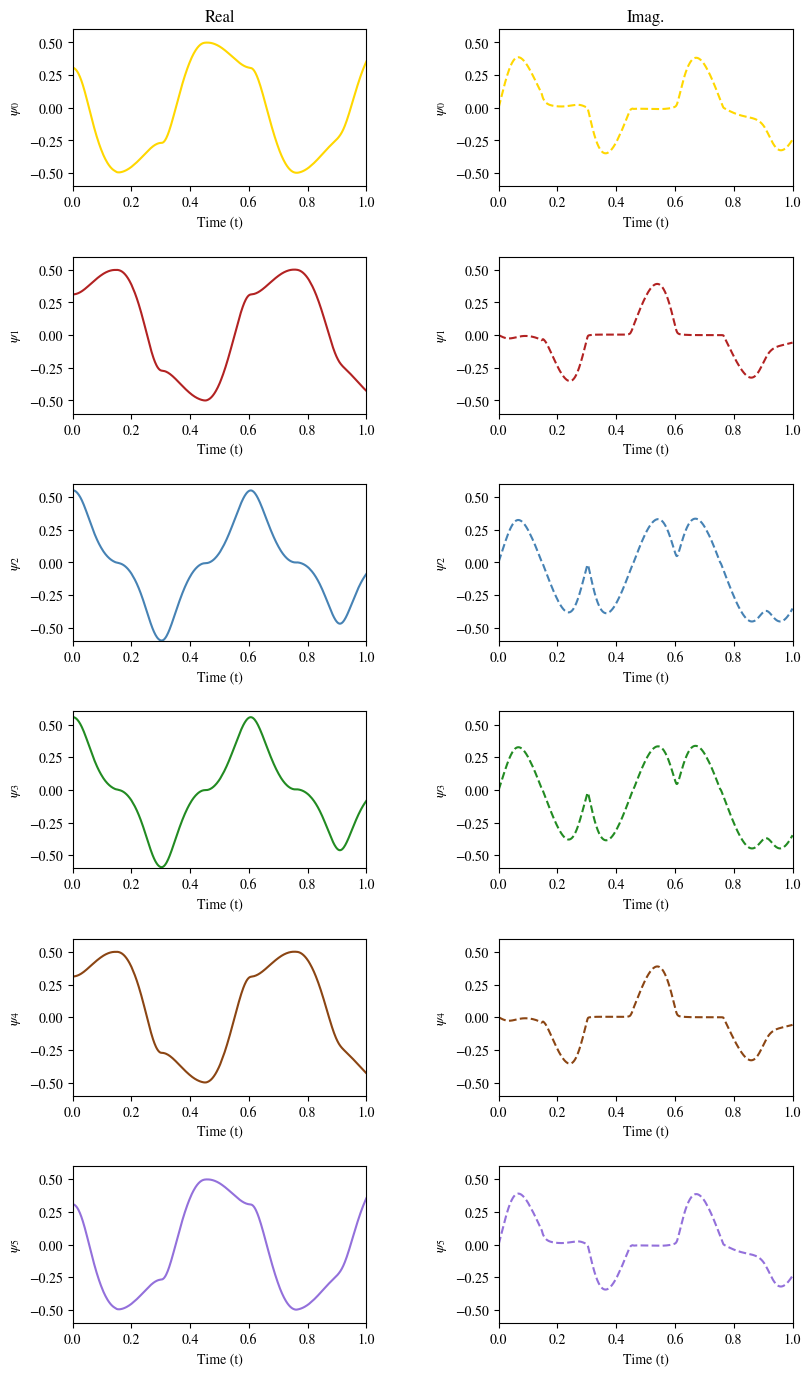

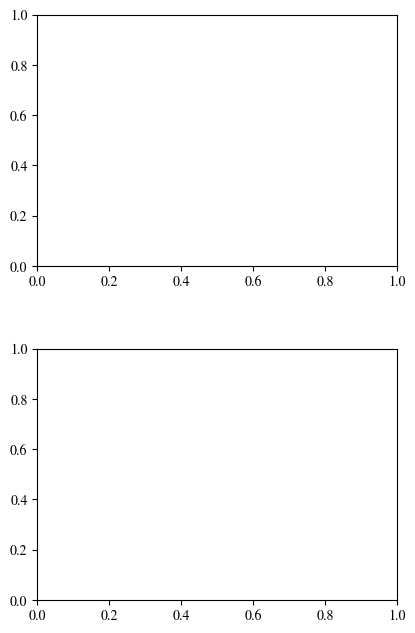

<Figure size 960x1400 with 0 Axes>

<Figure size 960x1680 with 0 Axes>

In [ ]:
import matplotlib

matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
from matplotlib.gridspec import GridSpec


def param_index_map(params):
    """Returns a list of length = total params, each entry is the key of that parameter."""
    leaves_with_paths = jax.tree_util.tree_leaves_with_path(params)
    index_map = []
    for path, leaf in leaves_with_paths:
        key = jax.tree_util.keystr(path)
        index_map.extend([key] * leaf.size)
    return index_map


save_times_number = 600
q = 0.0
n_samples = 2**14

for seed in [100, 200, 300, 400, 500]:
    fig = plt.figure(figsize=(1 * 4.8, 2 * 3.8))
    fig.subplots_adjust(left=0.15)
    gs = GridSpec(2, 1, figure=fig, wspace=0.45, hspace=0.33)
    ax_z = fig.add_subplot(gs[0, 0])
    ax_qgt = fig.add_subplot(gs[1, 0])

    fig_params = plt.figure(figsize=(2 * 4.8, 5 * 2.8))
    fig_params.subplots_adjust(left=0.15)
    gs_params = GridSpec(5, 2, figure=fig, wspace=0.45, hspace=0.45)

    fig_amps = plt.figure(figsize=(2 * 4.8, 6 * 2.8))
    fig_amps.subplots_adjust(left=0.15)
    gs_amps = GridSpec(6, 2, figure=fig, wspace=0.45, hspace=0.45)
    exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}_{seed}"
    save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    vstate = get_vstate(2**10, seed)
    params_all = []
    evals_all = []
    amplitudes = []
    for i in range(save_times_number):
        logger.restore()

        restored = logger.restore_state(vstate, var_name=f"_{i}")
        amplitudes.append(vstate.to_array(normalize=True))
        params_all.append(jax.flatten_util.ravel_pytree(vstate.parameters)[0])
        names = param_index_map(vstate.parameters)
        assert restored
    evals_all = logger.data["qgt_spectrum"]["values"]
    params_all = np.array(params_all)
    evals_all = np.array(evals_all)
    amplitudes = np.array(amplitudes)
    ### PARAMETERS ###
    colors = ["red", "crimson", "palevioletred", "hotpink", "mediumpurple"]
    for l in range(params_all.shape[1]):
        ax_params_re = fig_params.add_subplot(gs_params[l, 0])
        ax_params_im = fig_params.add_subplot(gs_params[l, 1])
        ax_params_re.plot(
            np.linspace(0, 1, save_times_number), params_all[:, l].real, color=colors[l]
        )
        ax_params_im.plot(
            np.linspace(0, 1, save_times_number),
            params_all[:, l].imag,
            color=colors[l],
            linestyle="dashed",
        )
        if l == 0:
            ax_params_re.set_title("Real")
            ax_params_im.set_title("Imag.")
        for ax_ in [ax_params_re, ax_params_im]:
            ax_.set_xlabel("Time (t)", fontsize=10)
            ax_.set_ylabel(names[l], fontsize=10)
            ax_.set_xlim(0, 1.0)
            ax_.set_ylim(-5.5, 5.5)
    print("Restored:", logger.restore())

    ### Z VALUES ###
    ax_z.plot(
        np.array(logger.data["t"]["values"]) / 4,
        np.array(logger.data["s_corr"]["Mean"]).real,
        label=f"q = {q:1.2f}",
        zorder=-1,
    )

    ax_z.set_xlabel("Time (t)", fontsize=20)
    ax_z.set_ylabel(r"$\langle Z_i \rangle$", fontsize=20)
    ax_z.tick_params(labelsize=20)
    loc_x = -0.18
    loc_y = 0.95
    ax_z.annotate("(c)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=20)

    ax_z.plot(
        times_exact_heisenberg / 4,
        np.real(magnetizations_exact_heisenberg),
        "k-",
        linewidth=2,
        label="ED",
        linestyle="dashed",
    )
    ax_z.legend(loc="lower right", fontsize=15)

    # ### EVALS QGT ###
    cmap = plt.get_cmap("viridis")
    for l in range(0, params_all.shape[0], 10):
        if l > params_all.shape[0] - 1:
            break
        ax_qgt.plot(np.abs(evals_all[l]), color=cmap((l / save_times_number)))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
    plt.colorbar(sm, ax=ax_qgt)
    ax_qgt.set_xlabel("$i$", fontsize=20)
    ax_qgt.set_ylabel(r"$\lambda_i$", fontsize=20)
    ax_qgt.set_yscale("log")
    # ax_qgt.set_yscale('log')
    # ### Checkerboard ###
    colors = [
        "gold",
        "firebrick",
        "steelblue",
        "forestgreen",
        "saddlebrown",
        "mediumpurple",
    ]
    for l in range(amplitudes.shape[1]):
        ax_amps_re = fig_amps.add_subplot(gs_amps[l, 0])
        ax_amps_im = fig_amps.add_subplot(gs_amps[l, 1])
        ax_amps_re.plot(
            np.linspace(0, 1, save_times_number), amplitudes[:, l].real, color=colors[l]
        )
        ax_amps_im.plot(
            np.linspace(0, 1, save_times_number),
            amplitudes[:, l].imag,
            color=colors[l],
            linestyle="dashed",
        )
        if l == 0:
            ax_amps_re.set_title("Real")
            ax_amps_im.set_title("Imag.")
        for ax_ in [ax_amps_re, ax_amps_im]:
            ax_.set_xlabel("Time (t)", fontsize=10)
            ax_.set_ylabel(rf"$\psi_{l}$", fontsize=10)
            ax_.set_xlim(0, 1.0)
            ax_.set_ylim(-0.6, 0.6)

    fig.savefig(f"Fig4c_{seed}_{q:1.2f}.pdf", bbox_inches="tight", pad_inches=0.01)
    fig_params.savefig(
        f"Fig4c_{seed}_{q:1.2f}_params.pdf", bbox_inches="tight", pad_inches=0.01
    )
    fig_amps.savefig(
        f"Fig4c_{seed}_{q:1.2f}_amps.pdf", bbox_inches="tight", pad_inches=0.01
    )

# Combined figures

In [40]:
import flax.linen as nn
import jax.numpy as jnp
from netket.hilbert import DiscreteHilbert

class AlphaBetaState(nn.Module):
    r"""Tiny Flax model with two scalar trainable parameters (alpha, beta).
    Intended to demonstrate initialization from python floats.
    """
    hilbert: DiscreteHilbert
    alpha0: complex = 0.0
    beta0: complex = 0.0

    @nn.compact
    def __call__(self, x_in):
        """Return a batch of log-psi values."""
        assert self.hilbert.size==1., "Only works for single qubit state"
        alpha = self.param("alpha", nn.initializers.constant(self.alpha0, dtype=complex), ())
        beta = self.param("beta", nn.initializers.constant(self.beta0, dtype=complex), ())
        out = jnp.where(x_in==1, alpha, beta)
        return jnp.log(out).squeeze()
    
hilbert = nk.hilbert.Spin(s=1 / 2, N=1)

def get_vstate(n_samples):
    # Small system because the dense S-matrix scales like O(N_params^2).
    # Increase L/alpha only if you really need the full dense matrix.
    seed = 100

    # Hilbert space: L spin-1/2 sites
    sampler = nk.sampler.MetropolisLocal(hilbert, n_chains = n_samples)

    # Model initialized from two python floats -> trainable params start at these values
    model = AlphaBetaState(
        hilbert=hilbert,
        alpha0=1.0,
        beta0=1.0,
    )

    # Variational Monte Carlo state
    vstate = nk.vqs.MCState(
        sampler=sampler,
        model=model,
        n_samples=n_samples,
        seed=seed
    )
    x = vstate.sample(n_samples=n_samples)
    psi = vstate.to_array()
    print(psi)
    return vstate



fields_to_track = (
    ("t", "values"),
    ("dt", "values"),
    ("Generator", "Mean"),
    ("Generator", "Variance"),
    ("sigma_z", "Mean"),
    ("sigma_z", "Variance"),
    ("r_squared", "values"),
    # Umbrella/bridge monitoring fields
    ("ess_bridge", "values"),
    ("snr_min", "values"),
    ("snr_10p", "values"),
    ("snr_med", "values"),
    ("snrF_min", "values"),
    ("snrF_med", "values"),
    ("q_bridge", "values"),
    # Per-step SNRs from OVar
    ("snr", "values"),
    ("snr_F", "values"),
    ("acceptance_rate", "values")
)

hamiltonian = nk.operator.PauliStringsJax(hilbert, "Y", 1.)
sigma_z = nk.operator.PauliStringsJax(hilbert, "Z", 1.)

def measure_sigma_z(step, log, driver):
    log['sigma_z'] = driver.state.expect(sigma_z)
    return True

In [41]:
import qutip as qt

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian.to_sparse()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)
vstate = get_vstate(2**10)
# Get initial state from vstate
psi0_array = vstate.to_array()
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create total magnetization operator (sum of Z_i)
# Convert netket operator to matrix
sigma_z_matrix = sigma_z.to_dense()
# Convert to QuTiP
Z_total_qutip = qt.Qobj(sigma_z_matrix)

# Time evolution parameters
T = 2.
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
magnetizations_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    mag = qt.expect(Z_total_qutip, psi_t)
    magnetizations_exact.append(mag)

[0.70710678+0.j 0.70710678+0.j]


Restored: True
Restored: True
No data found for `sigma_z` when restoring logger.
No data found for `acceptance_rate` when restoring logger.
Restored: True
No data found for `sigma_z` when restoring logger.
No data found for `acceptance_rate` when restoring logger.
Restored: True


/tmp/ipykernel_2067777/1539213728.py:87: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax_z_heisenberg.plot(
/tmp/ipykernel_2067777/1539213728.py:101: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  axins.plot(


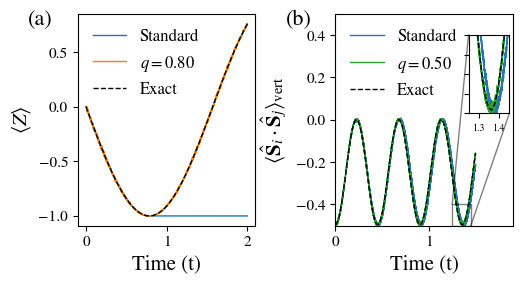

: 

In [ ]:
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"
n_samples_tvmc = 2**14
fig = plt.figure(figsize=(5.8, 5.5 / 2))
gs = GridSpec(1, 2, figure=fig, wspace=0.45, hspace=0.33)
ax_z = fig.add_subplot(gs[0, 0])
ax_z_heisenberg = fig.add_subplot(gs[0, 1])

# Add whitespace to the left of the plot
fig.subplots_adjust(left=0.15)
seed = 100
for q in [0.0, 0.8]:
    exp_name = f"blur_{n_samples_tvmc}_q_{q:1.2f}"
    save_path = f"./data/SIGMA_Y/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    ax_z.plot(
        logger.data["t"]["values"],
        np.array(logger.data["sigma_z"]["Mean"]).real,
        label="Standard" if q == 0 else f"$q=${q:1.2f}",
        lw=1,
    )
ax_z.plot(
    times_exact,
    magnetizations_exact,
    label="Exact",
    linestyle="--",
    color="black",
    lw=1,
)
loc_x = -0.18
loc_y = 0.95
ax_z.set_xlabel("Time (t)", fontsize=15)
ax_z.set_ylabel(r"$\langle Z\rangle$", fontsize=15)
ax_z.legend(
    frameon=False,
    fontsize=12,
)
ax_z.tick_params(labelsize=11)

q = 0
n_samples = 2**14
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}_{seed}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
t_heis_q0 = np.array(logger.data["t"]["values"]) / 4
s_heis_q0 = np.real(logger.data["s_corr"]["Mean"])
ax_z_heisenberg.plot(
    t_heis_q0,
    s_heis_q0,
    label=f"Standard",
    zorder=-1,
    lw=1,
)

q = 0.3
exp_name = f"blur_{n_samples}_DeltaJ_{deltaJ:1.2f}_q_{q:1.2f}_{seed}"
save_path = f"./data/HEISENBERG_{N}/{exp_name}/"
logger = Logger(path=save_path, fields=fields_to_track)
print("Restored:", logger.restore())
t_heis_q3 = np.array(logger.data["t"]["values"]) / 4
s_heis_q3 = np.real(logger.data["s_corr"]["Mean"])
ax_z_heisenberg.plot(
    t_heis_q3,
    s_heis_q3,
    label=f"$q = ${0.5:1.2f}",
    zorder=-1,
    lw=1,
    color="tab:green"
)

ax_z_heisenberg.set_xlabel("Time (t)", fontsize=15)
ax_z_heisenberg.set_ylabel(r"$\langle \hat{\mathbf{S}}_i \cdot \hat{\mathbf{S}}_j\rangle_{\mathrm{vert}}$", fontsize=15)
ax_z_heisenberg.tick_params(labelsize=11)
ax_z_heisenberg.set_ylim([-0.5, 0.5])
ax_z_heisenberg.set_xlim([0,1.9])

loc_x = -0.28
loc_y = 0.95
ax_z.annotate("(a)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16)
ax_z_heisenberg.annotate(
    "(b)", xy=(loc_x, loc_y), xycoords="axes fraction", fontsize=16
)

ax_z_heisenberg.plot(
    times_exact_heisenberg / 4,
    np.real(magnetizations_exact_heisenberg),
    "k-",
    linewidth=1,
    label="Exact",
    linestyle="dashed",
)
ax_z_heisenberg.legend(loc="upper left", frameon=False, fontsize=12)

# Zoom inset: t in [1.5, 1.75], <S.S> in [-0.5, -0.3]
axins = ax_z_heisenberg.inset_axes([0.75, 0.53, 0.23, 0.37])
axins.plot(t_heis_q0, s_heis_q0, lw=1)
axins.plot(t_heis_q3, s_heis_q3, lw=1, color="tab:green")
axins.plot(
    times_exact_heisenberg / 4,
    np.real(magnetizations_exact_heisenberg),
    "k-",
    linewidth=1,
    linestyle="dashed",
)
axins.set_xlim(1.25, 1.45)
axins.set_ylim(-0.5, -0.4)
axins.set_yticklabels([])
axins.tick_params(labelsize=7)
ax_z_heisenberg.indicate_inset_zoom(axins, edgecolor="black")

fig.savefig("Fig4.pdf", bbox_inches="tight", pad_inches=0.01)